In [153]:
import cv2
import os
import random
import numpy as np
from matplotlib import pyplot as plt

In [154]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

In [155]:
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [156]:
# os.makedirs(POS_PATH)
# os.makedirs(NEG_PATH)
# os.makedirs(ANC_PATH)

In [157]:
for directory in os.listdir('lfw-funneled'):
    for file in os.listdir(os.path.join('lfw-funneled', directory)):
        EX_PATH = os.path.join('lfw-funneled', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)

In [158]:
neg_files = os.listdir(NEG_PATH)

print(f"Total files in NEG_PATH: {len(neg_files)}")
    
print("Sample files in NEG_PATH:", neg_files[:10]) 

Total files in NEG_PATH: 26496
Sample files in NEG_PATH: ['36f6415c-0c51-11f0-bd0b-bc0ff35d5cb8.jpg', '376cf0f4-0c51-11f0-8706-bc0ff35d5cb8.jpg', '4abeef68-2382-11f0-9f19-bc0ff35d5cb8.jpg', '4e12dd3f-2382-11f0-9e60-bc0ff35d5cb8.jpg', 'Aaron_Eckhart_0001.jpg', 'Aaron_Eckhart_0001_1.jpg', 'Aaron_Guiel_0001.jpg', 'Aaron_Guiel_0001_1.jpg', 'Aaron_Patterson_0001.jpg', 'Aaron_Patterson_0001_1.jpg']


In [159]:
import uuid

In [160]:
os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))

'data\\anchor\\2d442e55-23fa-11f0-adc8-bc0ff35d5cb8.jpg'

In [161]:
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [162]:
import os

for path in [ANC_PATH, POS_PATH, NEG_PATH]:
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"📁 Created missing directory: {path}")


In [163]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Error: Could not access the webcam.")
else:
    print("✅ Webcam opened. Press 'C' to capture images, 'Q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Failed to capture frame.")
            break

        cv2.imshow("Camera - Press 'C' to capture", frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('c'):  
            img_name_anc = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
            img_name_pos = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
            img_name_neg = os.path.join(NEG_PATH, '{}.jpg'.format(uuid.uuid1()))

            cv2.imwrite(img_name_anc, frame)
            cv2.imwrite(img_name_pos, frame)
            cv2.imwrite(img_name_neg, frame)

            print(f"✅ Image saved in:\n - {img_name_anc}\n - {img_name_pos}\n - {img_name_neg}")

        elif key == ord('q'):  
            break

cap.release()
cv2.destroyAllWindows()

✅ Webcam opened. Press 'C' to capture images, 'Q' to quit.
✅ Image saved in:
 - data\anchor\3313c793-23fa-11f0-b325-bc0ff35d5cb8.jpg
 - data\positive\3313c794-23fa-11f0-9ae5-bc0ff35d5cb8.jpg
 - data\negative\3313c795-23fa-11f0-9013-bc0ff35d5cb8.jpg
✅ Image saved in:
 - data\anchor\33c0fa21-23fa-11f0-929c-bc0ff35d5cb8.jpg
 - data\positive\33c0fa22-23fa-11f0-adbe-bc0ff35d5cb8.jpg
 - data\negative\33c0fa23-23fa-11f0-885b-bc0ff35d5cb8.jpg


Final Frame Shape: (480, 640, 3)


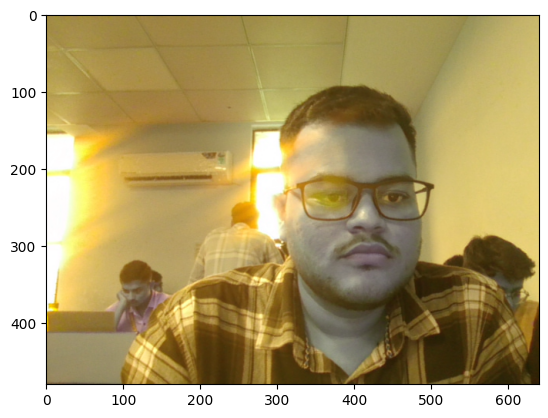

In [164]:
print("Final Frame Shape:", frame.shape)
plt.imshow(frame)

In [165]:
import os

POS_PATH = "data/positive"
NEG_PATH = "data/negative"
ANC_PATH = "data/anchor"

print(f"Positive samples: {len(os.listdir(POS_PATH))}")
print(f"Negative samples: {len(os.listdir(NEG_PATH))}")
print(f"Anchor samples: {len(os.listdir(ANC_PATH))}")


Positive samples: 5751
Negative samples: 26498
Anchor samples: 180


In [166]:
def data_aug(img):
    data = []
    for i in range(9):
        img = tf.image.stateless_random_brightness(img, max_delta=0.02, seed=(1,2))
        img = tf.image.stateless_random_contrast(img, lower=0.6, upper=1, seed=(1,3))
        # img = tf.image.stateless_random_crop(img, size=(20,20,3), seed=(1,2))
        img = tf.image.stateless_random_flip_left_right(img, seed=(np.random.randint(100),np.random.randint(100)))
        img = tf.image.stateless_random_jpeg_quality(img, min_jpeg_quality=90, max_jpeg_quality=100, seed=(np.random.randint(100),np.random.randint(100)))
        img = tf.image.stateless_random_saturation(img, lower=0.9,upper=1, seed=(np.random.randint(100),np.random.randint(100)))
            
        data.append(img)
    
    return data

In [167]:
import os
import uuid

In [168]:
img_path = os.path.join(ANC_PATH, '924e839c-135f-11ec-b54e-a0cec8d2d278.jpg')

In [169]:
print("ANC_PATH:", ANC_PATH)
print("Full Image Path:", img_path)

ANC_PATH: data/anchor
Full Image Path: data/anchor\924e839c-135f-11ec-b54e-a0cec8d2d278.jpg


In [170]:
ANC_PATH = r"C:\Users\Shubham Thakkar\Face\data\anchor"

In [171]:
import os

print("Files in ANC_PATH:", os.listdir(ANC_PATH))


Files in ANC_PATH: ['07047d85-0c10-11f0-bdd4-bc0ff35d5cb8.jpg', '0809aa02-0c10-11f0-a483-bc0ff35d5cb8.jpg', '0cd6dd53-0c11-11f0-90a6-bc0ff35d5cb8.jpg', '0da51be1-0c11-11f0-94ff-bc0ff35d5cb8.jpg', '10aafcfa-0c11-11f0-80e5-bc0ff35d5cb8.jpg', '10abe9ba-0c11-11f0-839a-bc0ff35d5cb8.jpg', '10ad2084-0c11-11f0-929a-bc0ff35d5cb8.jpg', '10ae3e2d-0c11-11f0-8525-bc0ff35d5cb8.jpg', '10af76a1-0c11-11f0-bb58-bc0ff35d5cb8.jpg', '10b08859-0c11-11f0-89b2-bc0ff35d5cb8.jpg', '10b1c0c2-0c11-11f0-8e8b-bc0ff35d5cb8.jpg', '10b2e677-0c11-11f0-9d99-bc0ff35d5cb8.jpg', '10b3f807-0c11-11f0-ab6c-bc0ff35d5cb8.jpg', '15e55c53-072a-11f0-9d16-bc0ff35d5cb8.jpg', '1795f78c-072a-11f0-a060-bc0ff35d5cb8.jpg', '1796703d-072a-11f0-859e-bc0ff35d5cb8.jpg', '1796be40-072a-11f0-9d78-bc0ff35d5cb8.jpg', '17973010-072a-11f0-8624-bc0ff35d5cb8.jpg', '179781f9-072a-11f0-85bf-bc0ff35d5cb8.jpg', '1797cfd2-072a-11f0-95e3-bc0ff35d5cb8.jpg', '179844b9-072a-11f0-a583-bc0ff35d5cb8.jpg', '17989339-072a-11f0-9287-bc0ff35d5cb8.jpg', '1798ddfb-07

In [172]:
img_path = os.path.join(ANC_PATH, '9ce65b92-03fc-11f0-b013-bc0ff35d5cb8.jpg')
img = cv2.imread(img_path)
augmented_images = data_aug(img)

for image in augmented_images:
    cv2.imwrite(os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1())), image.numpy())

In [173]:
# for file_name in os.listdir(os.path.join(POS_PATH)):
#     img_path = os.path.join(POS_PATH, file_name)
#     img = cv2.imread(img_path)
#     augmented_images = data_aug(img) 
    
#     for image in augmented_images:
#         cv2.imwrite(os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1())), image.numpy())

In [174]:
anchor = tf.data.Dataset.list_files(rf"{ANC_PATH}/*.jpg").take(3000)
positive = tf.data.Dataset.list_files(rf"{POS_PATH}/*.jpg").take(3000)
negative = tf.data.Dataset.list_files(rf"{NEG_PATH}/*.jpg").take(3000)

In [175]:
import os

if not os.path.exists(POS_PATH):
    print(f"❌ Error: The directory {POS_PATH} does not exist!")
else:
    # List all files in POS_PATH
    files = os.listdir(POS_PATH)
    print(f"✅ Found {len(files)} files in {POS_PATH}")
    print("Sample files:", files[:5])  # Show the first 5 files


✅ Found 5751 files in data/positive
Sample files: ['001657d6-072b-11f0-87c3-bc0ff35d5cb8.jpg', '003c022a-072b-11f0-8077-bc0ff35d5cb8.jpg', '003cc58c-072b-11f0-be64-bc0ff35d5cb8.jpg', '003d61db-072b-11f0-9bbb-bc0ff35d5cb8.jpg', '003dfdf8-072b-11f0-a2c7-bc0ff35d5cb8.jpg']


In [176]:
dir_test = anchor.as_numpy_iterator()

In [177]:
print(dir_test.next())

b'C:\\Users\\Shubham Thakkar\\Face\\data\\anchor\\5bafea3a-0bfd-11f0-a8e5-bc0ff35d5cb8.jpg'


In [178]:
def preprocess1(file_path):
  
    byte_img = tf.io.read_file(file_path)
 
    img = tf.io.decode_jpeg(byte_img)
    
    img = tf.image.resize(img, (100,100))

    img = img / 255.0

    return img

In [179]:
img = preprocess1('data\\anchor\\ef5b5f9c-058f-11f0-b23c-bc0ff35d5cb8.jpg')

In [180]:
img.numpy().max() 

0.71450955

In [181]:
dataset = tf.data.Dataset.zip((anchor, positive, negative))

In [182]:
import tensorflow as tf

dataset = tf.data.Dataset.zip((anchor, positive, negative))
print("✅ Dataset created successfully!")


✅ Dataset created successfully!


In [183]:
for sample in dataset.take(1):
    print(sample)

(<tf.Tensor: shape=(), dtype=string, numpy=b'C:\\Users\\Shubham Thakkar\\Face\\data\\anchor\\10ae3e2d-0c11-11f0-8525-bc0ff35d5cb8.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\da3f23a6-072a-11f0-ae68-bc0ff35d5cb8.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\negative\\Vincent_Spadea_0001_1.jpg'>)


In [184]:
def preprocess(anchor, positive, negative):
    return (anchor/255.0, positive/255.0, negative/255.0)

In [185]:
import tensorflow as tf

def load_and_preprocess_image(path):
    img = tf.io.read_file(path)  
    img = tf.image.decode_jpeg(img, channels=3)  
    img = tf.image.resize(img, [100, 100]) 
    img = tf.cast(img, tf.float32) / 255.0  
    return img

In [186]:
anchor = anchor.map(load_and_preprocess_image)
positive = positive.map(load_and_preprocess_image)
negative = negative.map(load_and_preprocess_image)

dataset = tf.data.Dataset.zip((anchor, positive, negative))  # Now contains images

def preprocess(anchor, positive, negative):
    return (anchor, positive, negative)  # No need to divide by 255 again

dataset = dataset.map(preprocess)


In [187]:
dataset = dataset.map(preprocess)
print("✅ Mapping function applied!")

✅ Mapping function applied!


In [188]:
dataset.map(preprocess)

<_MapDataset element_spec=(TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None))>

In [189]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [190]:
samples = data.as_numpy_iterator()

In [191]:
exampple = samples.next()

In [192]:
exampple

(array([[[0.25517645, 0.23596078, 0.20184313],
         [0.22705881, 0.23486274, 0.19360785],
         [0.23607844, 0.24392158, 0.21098039],
         ...,
         [0.20235294, 0.21411765, 0.16117646],
         [0.21996069, 0.2317254 , 0.18858814],
         [0.21254897, 0.21254897, 0.16549015]],
 
        [[0.22823529, 0.23572549, 0.18082353],
         [0.2097647 , 0.23384315, 0.17866667],
         [0.22098039, 0.24666667, 0.19823529],
         ...,
         [0.23607844, 0.2419608 , 0.20078431],
         [0.20250976, 0.22603917, 0.17898035],
         [0.22349013, 0.23133327, 0.188196  ]],
 
        [[0.2254902 , 0.24117647, 0.17450981],
         [0.22235292, 0.25019607, 0.19313726],
         [0.21862745, 0.24607843, 0.19509804],
         ...,
         [0.20784314, 0.2254902 , 0.18235295],
         [0.20980392, 0.2407844 , 0.18647054],
         [0.21960784, 0.24705882, 0.19803922]],
 
        ...,
 
        [[0.4313725 , 0.46274504, 0.41176465],
         [0.45647046, 0.48784304, 0.43686

In [193]:
def preprocess_twin(input_img, validation_img, label):
    return (input_img, validation_img, label)

In [194]:
res = preprocess_twin(*exampple)

In [195]:
print("Min:", res[1].min(), "Max:", res[1].max())

Min: 0.13486335 Max: 0.59980386


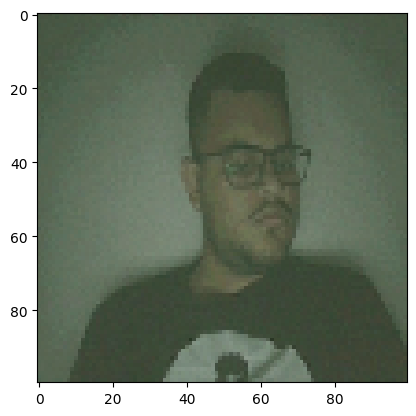

In [196]:
plt.imshow(res[1])

In [197]:
res[2]

1.0

In [198]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=10000)

In [199]:
# print(test_data)

In [200]:
# Training partition
train_data = data.take(round(len(data) * 0.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [201]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

In [202]:
for batch in test_data.as_numpy_iterator():
    print("Labels in this batch (y_true):", batch[2])

Labels in this batch (y_true): [0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0.]
Labels in this batch (y_true): [1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]
Labels in this batch (y_true): [0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1.]
Labels in this batch (y_true): [1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0.]
Labels in this batch (y_true): [0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0.]
Labels in this batch (y_true): [0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1.]
Labels in this batch (y_true): [0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0.]
Labels in this batch (y_true): [1.]


In [203]:
inp = Input(shape=(100,100,3), name='input_image')

In [204]:
c1 = Conv2D(64, (10,10), activation='relu')(inp)

In [205]:
m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

In [206]:
c2 = Conv2D(128, (7,7), activation='relu')(m1)
m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

In [207]:
c3 = Conv2D(128, (4,4), activation='relu')(m2)
m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

In [208]:
c4 = Conv2D(256, (4,4), activation='relu')(m3)
f1 = Flatten()(c4)
d1 = Dense(4096, activation='sigmoid')(f1)

In [209]:
mod = Model(inputs=[inp], outputs=[d1], name='embedding')

In [210]:
mod.summary()

Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 91, 91, 64)          │          19,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 40, 40, 128)         │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 17, 17, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 6, 6, 256)           │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4096)                │      37,752,832 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

In [211]:
def make_embedding(): 
    inp = Input(shape=(100,100,3), name='input_image')
    
    # First block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)
    
    # Second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)
    
    # Third block 
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)
    
    # Final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)
    
    
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [212]:
embedding = make_embedding()

In [213]:
embedding.summary()

Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 91, 91, 64)          │          19,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 40, 40, 128)         │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 17, 17, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 6, 6, 256)           │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4096)                │      37,752,832 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

In [214]:
# Siamese L1 Distance class
class L1Dist(Layer):
    
    # Init method - inheritance
    def __init__(self, **kwargs):
        super().__init__()
       
    # Magic happens here - similarity calculation
    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [215]:
l1 = L1Dist()

In [216]:
# Example input images (replace with actual images)
# Generate random image tensors to check if embeddings are distinct
anchor_img = tf.random.uniform((1, 100, 100, 3))
validation_img = tf.random.uniform((1, 100, 100, 3))

# Generate embeddings
anchor_embedding = embedding(anchor_img)
validation_embedding = embedding(validation_img)

# Print embeddings to check if they are different
print("Anchor Embedding:", anchor_embedding.numpy())
print("Validation Embedding:", validation_embedding.numpy())


# Generate embeddings
anchor_embedding = embedding(anchor_img)  
validation_embedding = embedding(validation_img)

# Now use L1 distance layer
distance = l1(anchor_embedding, validation_embedding)
print("Distance Shape:", distance.shape)


Anchor Embedding: [[0.48628896 0.49513155 0.50624907 ... 0.48117533 0.5085187  0.4993652 ]]
Validation Embedding: [[0.48465195 0.49411923 0.5055745  ... 0.47925973 0.51140785 0.5006474 ]]
Distance Shape: (1, 4096)


In [217]:
# Now use L1 distance layer
distance = l1(anchor_embedding, validation_embedding)
print("Distance Shape:", distance.shape)
print("Distance Tensor:", distance.numpy())


Distance Shape: (1, 4096)
Distance Tensor: [[0.00163701 0.00101233 0.00067455 ... 0.0019156  0.00288916 0.00128222]]


In [218]:
anchor_img = tf.random.uniform((1, 100, 100, 3))
validation_img = tf.random.uniform((1, 100, 100, 3))
anchor_embedding = embedding(anchor_img)
validation_embedding = embedding(validation_img)
print("Anchor Embedding:", anchor_embedding.numpy())
print("Validation Embedding:", validation_embedding.numpy())


Anchor Embedding: [[0.4865783  0.49573946 0.5043931  ... 0.4808309  0.5089148  0.49750352]]
Validation Embedding: [[0.48607388 0.4949156  0.50616175 ... 0.47869262 0.50884515 0.4971814 ]]


In [219]:
print("Distance Tensor:", distance)

Distance Tensor: tf.Tensor([[0.00163701 0.00101233 0.00067455 ... 0.0019156  0.00288916 0.00128222]], shape=(1, 4096), dtype=float32)


In [220]:
l1(anchor_embedding, validation_embedding)

<tf.Tensor: shape=(1, 4096), dtype=float32, numpy=
array([[5.0440431e-04, 8.2385540e-04, 1.7686486e-03, ..., 2.1382868e-03,
        6.9677830e-05, 3.2213330e-04]], dtype=float32)>

In [221]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class L1Dist(Layer):    
    def __init__(self, **kwargs):
        super().__init__()

    def call(self, input_embedding, validation_embedding):
        # Ensure tensors are explicitly cast and their shape is correct
        input_embedding = tf.convert_to_tensor(input_embedding)
        validation_embedding = tf.convert_to_tensor(validation_embedding)

        # Remove extra dimensions if needed
        input_embedding = tf.squeeze(input_embedding, axis=0)
        validation_embedding = tf.squeeze(validation_embedding, axis=0)

        return tf.math.abs(input_embedding - validation_embedding)

In [222]:
# Inputs
input_image = Input(name='input_img', shape=(100,100,3))
validation_image = Input(name='validation_img', shape=(100,100,3))

# Get embeddings
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

# Compute L1 Distance (No more TypeError)
siamese_layer = L1Dist()  # Use the corrected layer
distances = siamese_layer(inp_embedding, val_embedding)  # ✅ No TypeError!

# Classification Layer
classifier = Dense(1, activation='sigmoid')(distances)


In [223]:
input_image = Input(name='input_img', shape=(100,100,3))
validation_image = Input(name='validation_img', shape=(100,100,3))

In [224]:
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

In [225]:
siamese_layer = L1Dist()

In [226]:
distances = siamese_layer(inp_embedding, val_embedding)

In [227]:
classifier = Dense(1, activation='sigmoid')(distances)

In [228]:
classifier

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=keras_tensor_172>

In [229]:
siamese_network = Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [230]:
siamese_network.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)        │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ validation_img (InputLayer)   │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Functional)        │ (None, 4096)              │      38,960,448 │ input_img[0][0],           │
│                               │                           │                 │ validation_img[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l1_dist_9 (L1Dist)            │ (None, 4096)              │               0 │ embedding[2][0],           │
│                               │                           │                 │ embedding[3][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 1)                 │           4,097 │ l1_dist_9[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [231]:
def make_siamese_model(): 
    
    # Anchor image input in the network
    input_image = Input(name='input_img', shape=(100,100,3))
    
    # Validation image in the network 
    validation_image = Input(name='validation_img', shape=(100,100,3))
    
    # Combine siamese distance components
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))
    
    # Classification layer 
    classifier = Dense(1, activation='sigmoid')(distances)
    
    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [232]:
siamese_model = make_siamese_model()

In [233]:
siamese_model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)        │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ validation_img (InputLayer)   │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Functional)        │ (None, 4096)              │      38,960,448 │ input_img[0][0],           │
│                               │                           │                 │ validation_img[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l1_dist_10 (L1Dist)           │ (None, 4096)              │               0 │ embedding[4][0],           │
│                               │                           │                 │ embedding[5][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 1)                 │           4,097 │ l1_dist_10[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [234]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [235]:
opt = tf.keras.optimizers.Adam(1e-4) # 0.0001

In [236]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

In [237]:
test_batch = train_data.as_numpy_iterator()

In [238]:
batch_1 = test_batch.next()

In [239]:
X = batch_1[:2]

In [240]:
y = batch_1[2]

In [241]:
y

array([1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.],
      dtype=float32)

In [242]:
tf.losses.BinaryCrossentropy??

Init signature:
tf.losses.BinaryCrossentropy(
    from_logits=False,
    label_smoothing=0.0,
    axis=-1,
    reduction='sum_over_batch_size',
    name='binary_crossentropy',
    dtype=None,
)
Source:        
@keras_export("keras.losses.BinaryCrossentropy")
class BinaryCrossentropy(LossFunctionWrapper):
    """Computes the cross-entropy loss between true labels and predicted labels.

    Use this cross-entropy loss for binary (0 or 1) classification applications.
    The loss function requires the following inputs:

    - `y_true` (true label): This is either 0 or 1.
    - `y_pred` (predicted value): This is the model's prediction, i.e, a single
        floating-point value which either represents a
        [logit](https://en.wikipedia.org/wiki/Logit), (i.e, value in [-inf, inf]
        when `from_logits=True`) or a probability (i.e, value in [0., 1.] when
        `from_logits=False`).

    Args:
        from_logits: Whether to interpret `y_pred` as a tensor of
            [logit](htt

In [243]:
@tf.function
def train_step(batch):
    
    with tf.GradientTape() as tape:     
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        yhat = siamese_model(X, training=True)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)
        
    grad = tape.gradient(loss, siamese_model.trainable_variables)
    
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))
        
    # Return loss
    return loss

In [244]:
from tensorflow.keras.metrics import Precision, Recall

In [245]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Creating a metric object 
        r = Recall()
        p = Precision()
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            loss = train_step(batch)
            yhat = siamese_model.predict(batch[:2])
            r.update_state(batch[2], yhat)
            p.update_state(batch[2], yhat) 
            progbar.update(idx+1)
        print(loss.numpy(), r.result().numpy(), p.result().numpy())
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)

In [246]:
EPOCHS = 50

In [247]:
train(train_data, EPOCHS)


 Epoch 1/50
Tensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/steps/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/stepstep 
Tensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 412s 20s/step
0.24815443 0.62222224 0.93333334

 Epoch 2/50
1

KeyboardInterrupt: 

In [248]:
from tensorflow.keras.metrics import Precision, Recall

In [249]:
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [250]:
y_hat = siamese_model.predict([test_input, test_val])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [251]:
# Post processing the results 
[1 if prediction > 0.8 else 0 for prediction in y_hat ]

[0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0]

In [252]:
y_true

array([0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0.],
      dtype=float32)

In [253]:
# Creating a metric object 
m = Recall()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

1.0

In [254]:
# Creating a metric object 
m = Precision()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

1.0

In [256]:
r = Recall()
p = Precision()

for test_input, test_val, y_true in test_data.as_numpy_iterator():
    yhat = siamese_model.predict([test_input, test_val])
    r.update_state(y_true, yhat)
    p.update_state(y_true,yhat) 

print(r.result().numpy(), p.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1.0 0.98333335


Rescaled Test Input Min: 0 Max: 255
Rescaled Test Val Min: 0 Max: 255


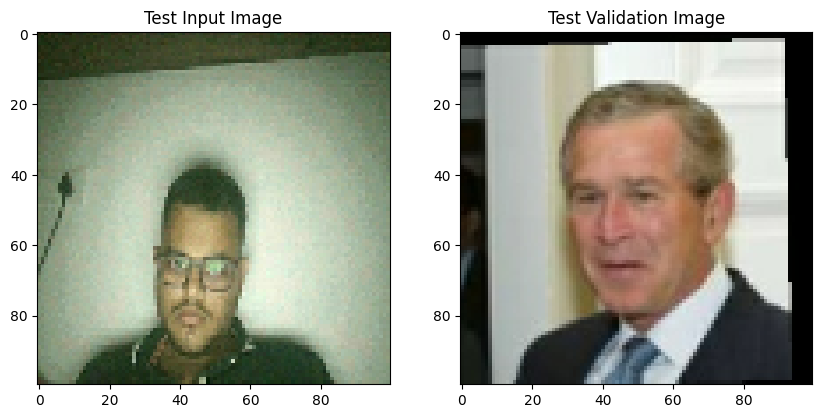

In [257]:
import numpy as np
import matplotlib.pyplot as plt

# Rescale images to 0-255
test_input_vis = ((test_input[0] - test_input.min()) * (255 / (test_input.max() - test_input.min()))).astype("uint8")
test_val_vis = ((test_val[0] - test_val.min()) * (255 / (test_val.max() - test_val.min()))).astype("uint8")


print("Rescaled Test Input Min:", test_input_vis.min(), "Max:", test_input_vis.max())
print("Rescaled Test Val Min:", test_val_vis.min(), "Max:", test_val_vis.max())

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Test Input Image")
plt.imshow(test_input_vis)

plt.subplot(1, 2, 2)
plt.title("Test Validation Image")
plt.imshow(test_val_vis)

plt.show()


In [258]:
# Save weights
siamese_model.save('siamesemodelv4.h5')

In [259]:
siamese_model.save('siamesemodelv4.keras')

In [260]:
from tensorflow.keras.models import load_model

# Load the model with custom objects if you used a custom layer like L1Dist
siamese_model = load_model("siamesemodelv2.h5", custom_objects={'L1Dist': L1Dist, 'BinaryCrossentropy': tf.losses.BinaryCrossentropy})


In [261]:
# from tensorflow.keras.models import load_model

# # Load the Keras model
# siamese_model = load_model("siamesemodelv2.keras")


In [262]:
siamese_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [263]:
L1Dist

__main__.L1Dist

In [264]:
siamese_model = tf.keras.models.load_model('siamesemodelv2.h5', 
                                   custom_objects={'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})

In [265]:
# Make predictions with reloaded model
siamese_model.predict([test_input, test_val])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.02660381]], dtype=float32)

In [266]:
# View model summary
siamese_model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)        │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ validation_img (InputLayer)   │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Functional)        │ (None, 4096)              │      38,960,448 │ input_img[0][0],           │
│                               │                           │                 │ validation_img[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l1_dist_12 (L1Dist)           │ (None, 4096)              │               0 │ embedding[0][0],           │
│                               │                           │                 │ embedding[1][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_17 (Dense)              │ (None, 1)                 │           4,097 │ l1_dist_12[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [267]:
import os

# Define the path
test_images_path = 'application_data/test_images'

# Check if the directory exists, if not, create it
if not os.path.exists(test_images_path):
    os.makedirs(test_images_path)
    print(f"Created missing directory: {test_images_path}")
else:
    print(f"Directory exists: {test_images_path}")


Directory exists: application_data/test_images


In [268]:
print("Looking for images in:", os.path.join('applic`ation_data', 'verification_images'))

Looking for images in: applic`ation_data\verification_images


In [270]:
# application_data\verification_images

In [271]:
os.listdir(os.path.join('application_data', 'verification_images'))

['15e55c53-072a-11f0-9d16-bc0ff35d5cb8.jpg',
 '1795f78c-072a-11f0-a060-bc0ff35d5cb8.jpg',
 '1796be40-072a-11f0-9d78-bc0ff35d5cb8.jpg',
 '633d3dce-0623-11f0-91a9-bc0ff35d5cb8.jpg',
 'a9dcfd22-040f-11f0-b06f-bc0ff35d5cb8.jpg',
 'a9de0e97-040f-11f0-9690-bc0ff35d5cb8.jpg',
 'bb650148-058f-11f0-b7a7-bc0ff35d5cb8.jpg',
 'bbc8f473-058f-11f0-bb58-bc0ff35d5cb8.jpg']

In [272]:
os.path.join('application_data', 'input_image', 'input_image.jpg')

'application_data\\input_image\\input_image.jpg'

In [273]:
for image in os.listdir(os.path.join('application_data', 'verification_images')):
    validation_img = os.path.join('application_data', 'verification_images', image)
    print(validation_img)

application_data\verification_images\15e55c53-072a-11f0-9d16-bc0ff35d5cb8.jpg
application_data\verification_images\1795f78c-072a-11f0-a060-bc0ff35d5cb8.jpg
application_data\verification_images\1796be40-072a-11f0-9d78-bc0ff35d5cb8.jpg
application_data\verification_images\633d3dce-0623-11f0-91a9-bc0ff35d5cb8.jpg
application_data\verification_images\a9dcfd22-040f-11f0-b06f-bc0ff35d5cb8.jpg
application_data\verification_images\a9de0e97-040f-11f0-9690-bc0ff35d5cb8.jpg
application_data\verification_images\bb650148-058f-11f0-b7a7-bc0ff35d5cb8.jpg
application_data\verification_images\bbc8f473-058f-11f0-bb58-bc0ff35d5cb8.jpg


In [274]:
def verify(model, detection_threshold, verification_threshold):
    # Build results array
    results = []
    vis_img = []
    for image in os.listdir(os.path.join('application_data', 'verification_images')):
        input_img = preprocess1(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        validation_img = preprocess1(os.path.join('application_data', 'verification_images', image))
        
        # Make Predictions 
        result = model.predict([np.expand_dims(input_img, axis=0), np.expand_dims(validation_img, axis=0)])
        vis_img.append(os.path.join('application_data', 'verification_images', image))
        results.append(result)
    
    # Detection Threshold: Metric above which a prediciton is considered positive 
    detection = np.sum(np.array(results) > detection_threshold)
    
    # Verification Threshold: Proportion of positive predictions / total positive samples 
    verification = detection / len(os.listdir(os.path.join('application_data', 'verification_images'))) 
    verified = verification > verification_threshold
    
    return results, verified, vis_img

In [275]:
results, verified, vis_img = verify(siamese_model, 0.5, 0.2)
print("Verification Result:", verified)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
Verification Result: True


In [276]:
np.sum(np.squeeze(results) > 0.9)

0

In [277]:
results

[array([[0.62099344]], dtype=float32),
 array([[0.23588113]], dtype=float32),
 array([[0.28889582]], dtype=float32),
 array([[0.65813696]], dtype=float32),
 array([[0.29281262]], dtype=float32),
 array([[0.26731962]], dtype=float32),
 array([[0.87150484]], dtype=float32),
 array([[0.88256556]], dtype=float32)]